# PEDS — experimentos completos (curvas, tabelas, eficiência de dados, AL)

5 surrogates do paper. Curvas baseline vs PEDS, 2 tabelas da página 21, sweep de tamanho
(eficiência de dados) + tabela-veredito do "mais com menos", e active learning do Maxwell.
`N_ENSEMBLE=5` aplica a média de 5 modelos **nos dois lados** (PEDS e NN-only), como no paper.

In [1]:
# Célula 1 — setup
%matplotlib inline
import os, sys, torch
sys.path.append(os.path.abspath('..'))
from src.peds_experiments import (EXPERIMENTS, run_diffusion_experiment,
                                   plot_learning_curve, plot_replication_tables,
                                   run_size_sweep, plot_size_sweep, plot_efficiency_table)
from src.maxwell_experiment import (run_maxwell_experiment,
                                     run_maxwell_active_learning, plot_al_curve)
DATA_ROOT = os.path.abspath('../data')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_ENSEMBLE = 5          # 1 = modelo único | 5 = ensemble do paper (PEDS e NN-only, treina 5x)
print('device:', DEVICE, '| ensemble:', N_ENSEMBLE)
results = {}

/opt/conda/lib/python3.10/site-packages/torch/cuda/__init__.py:51: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[PEDS Init] Aceleração de Hardware configurada para: cuda
[PEDS Init] Executando em modo Single-Process / Local.
device: cuda | ensemble: 5


## Experimentos 1–4: difusão (Fourier) e reação-difusão (Fisher)

=== Fourier(16) ===



--- Telemetria Consolidada com Sucesso: ./logs/experimento_Fourier16_PEDS_m0_20260601_181944.csv ---
          Timestamp                                     SO                GPU_Nome         Modelo_IA Total_Parametros  Época  Tempo_Treino_(s) Uso_CPU_Geral CPU_Livre  CPU_Nucleos_Totais  CPU_Nucleos_Ativos  RAM_Total_(GB)  RAM_SO_(GB)  RAM_IA_(GB)  RAM_Livre_(GB) RAM_P_IA RAM_P_SO RAM_P_Livre  VRAM_Total_(MB)  VRAM_SO_(MB)  VRAM_IA_(MB)  VRAM_Livre_(MB) GPU_P_IA GPU_P_SO GPU_P_Livre  Temp_GPU_(°C)
2026-06-01 18:12:06 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Fourier16_PEDS_m0           20,753      1              2.44          7.6%     92.4%                  16                   2           15.58         1.91         0.77           12.90    4.94%   12.26%       82.8%           8188.0       2928.81         17.23          5241.96    0.21%   35.77%      64.02%             46
2026-06-01 18:12:10 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Fourier16_P

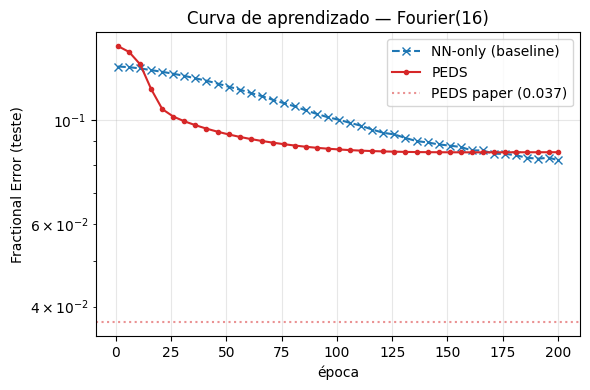

=== Fourier(25) ===

--- Telemetria Consolidada com Sucesso: ./logs/experimento_Fourier25_PEDS_m0_20260601_185835.csv ---
          Timestamp                                     SO                GPU_Nome         Modelo_IA Total_Parametros  Época  Tempo_Treino_(s) Uso_CPU_Geral CPU_Livre  CPU_Nucleos_Totais  CPU_Nucleos_Ativos  RAM_Total_(GB)  RAM_SO_(GB)  RAM_IA_(GB)  RAM_Livre_(GB) RAM_P_IA RAM_P_SO RAM_P_Livre  VRAM_Total_(MB)  VRAM_SO_(MB)  VRAM_IA_(MB)  VRAM_Livre_(MB) GPU_P_IA GPU_P_SO GPU_P_Livre  Temp_GPU_(°C)
2026-06-01 18:50:56 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Fourier25_PEDS_m0           23,066      1              2.06         12.5%     87.5%                  16                   7           15.58         1.94         0.84           12.80    5.39%   12.45%      82.16%           8188.0       2900.77         17.61          5269.62    0.22%   35.43%      64.35%             44
2026-06-01 18:50:59 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce 

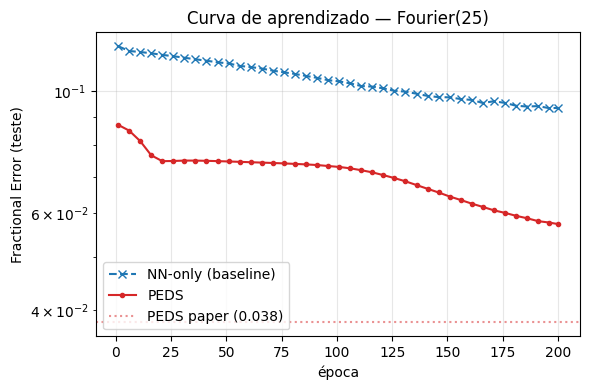

=== Fisher(16) ===

--- Telemetria Consolidada com Sucesso: ./logs/experimento_Fisher16_PEDS_m0_20260601_193748.csv ---
          Timestamp                                     SO                GPU_Nome        Modelo_IA Total_Parametros  Época  Tempo_Treino_(s) Uso_CPU_Geral CPU_Livre  CPU_Nucleos_Totais  CPU_Nucleos_Ativos  RAM_Total_(GB)  RAM_SO_(GB)  RAM_IA_(GB)  RAM_Livre_(GB) RAM_P_IA RAM_P_SO RAM_P_Livre  VRAM_Total_(MB)  VRAM_SO_(MB)  VRAM_IA_(MB)  VRAM_Livre_(MB) GPU_P_IA GPU_P_SO GPU_P_Livre  Temp_GPU_(°C)
2026-06-01 19:30:05 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Fisher16_PEDS_m0           20,753      1              2.10         13.6%     86.4%                  16                   9           15.58         1.94         0.85           12.79    5.46%   12.45%      82.09%           8188.0       2936.40         17.23          5234.37    0.21%   35.86%      63.93%             47
2026-06-01 19:30:09 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 

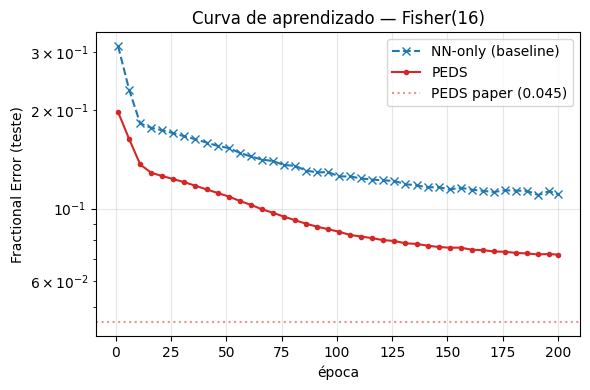

=== Fisher(25) ===

--- Telemetria Consolidada com Sucesso: ./logs/experimento_Fisher25_PEDS_m0_20260601_201654.csv ---
          Timestamp                                     SO                GPU_Nome        Modelo_IA Total_Parametros  Época  Tempo_Treino_(s) Uso_CPU_Geral CPU_Livre  CPU_Nucleos_Totais  CPU_Nucleos_Ativos  RAM_Total_(GB)  RAM_SO_(GB)  RAM_IA_(GB)  RAM_Livre_(GB) RAM_P_IA RAM_P_SO RAM_P_Livre  VRAM_Total_(MB)  VRAM_SO_(MB)  VRAM_IA_(MB)  VRAM_Livre_(MB) GPU_P_IA GPU_P_SO GPU_P_Livre  Temp_GPU_(°C)
2026-06-01 20:09:09 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Fisher25_PEDS_m0           23,066      1              2.16         13.8%     86.2%                  16                  11           15.58         1.96         0.84           12.78    5.39%   12.58%      82.03%           8188.0       2882.51         17.61          5287.88    0.22%    35.2%      64.58%             43
2026-06-01 20:09:13 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 

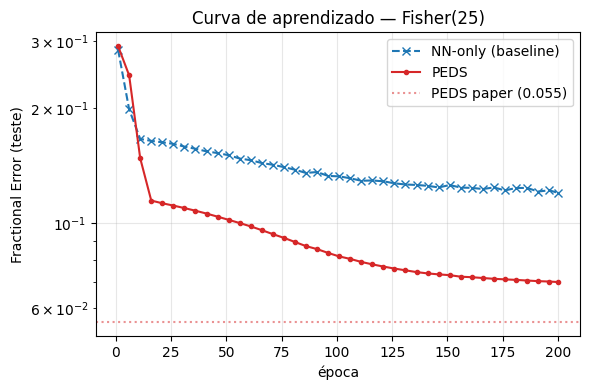

In [2]:
# Célula 2 — Fourier(16/25), Fisher(16/25)
for name in EXPERIMENTS:
    print(f'=== {name} ===')
    r = run_diffusion_experiment(name, DATA_ROOT, device=DEVICE,
                                 telemetry=True, n_ensemble=N_ENSEMBLE)
    results[name] = r
    print(f"  PEDS={r['final_peds']:.3f} | NN-only={r['final_nn']:.3f} | "
          f"low-fi={r['lowfi']:.3f} | w={r['w']:.3f}")
    plot_learning_curve(r)

## Experimento 5: Maxwell(10) — treino estático (PEDS vs NN-only, ambos ensemble)


--- Telemetria Consolidada com Sucesso: ./logs/experimento_Maxwell10_PEDS_m0_20260601_205022.csv ---
          Timestamp                                     SO                GPU_Nome         Modelo_IA Total_Parametros  Época  Tempo_Treino_(s) Uso_CPU_Geral CPU_Livre  CPU_Nucleos_Totais  CPU_Nucleos_Ativos  RAM_Total_(GB)  RAM_SO_(GB)  RAM_IA_(GB)  RAM_Livre_(GB) RAM_P_IA RAM_P_SO RAM_P_Livre  VRAM_Total_(MB)  VRAM_SO_(MB)  VRAM_IA_(MB)  VRAM_Livre_(MB) GPU_P_IA GPU_P_SO GPU_P_Livre  Temp_GPU_(°C)
2026-06-01 20:48:34 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Maxwell10_PEDS_m0          765,774      1             11.20         53.7%     46.3%                  16                  16           15.58         1.94         1.01           12.63    6.48%   12.45%      81.07%           8188.0       2609.28         29.05          5549.67    0.35%   31.87%      67.78%             44
2026-06-01 20:48:45 Linux 6.6.87.2-microsoft-standard-WSL2 NVIDIA GeForce RTX 4060 Maxwell10_P

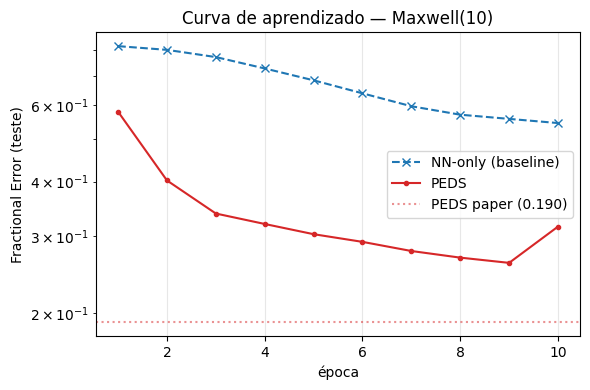

'./figs/learning_curve_Maxwell10.png'

In [3]:
# Célula 3 — Maxwell(10) estático
rm = run_maxwell_experiment(DATA_ROOT, device=DEVICE, telemetry=True,
                            grad_clip=1.0, n_ensemble=N_ENSEMBLE)
results['Maxwell(10)'] = rm
print(f"PEDS={rm['final_peds']:.3f} | NN-only={rm['final_nn']:.3f} | "
      f"low-fi={rm['lowfi']:.3f} | w={rm['w']:.3f}")
plot_learning_curve(rm)

## As 2 tabelas da página 21 (premissa de ACURÁCIA)
Tabela 2 = PEDS vs NN-only; Tabela 3 = PEDS vs low-fidelity. Mostram que o PEDS é mais
preciso com o MESMO (pouco) dado. A premissa de eficiência de dados ("menos dados") está
no sweep abaixo, não aqui.

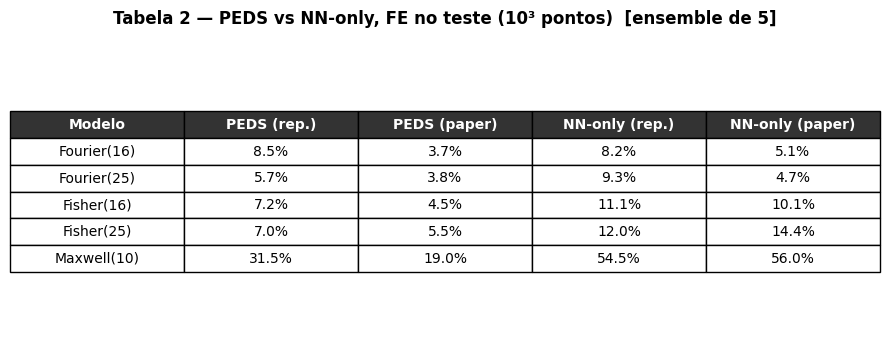

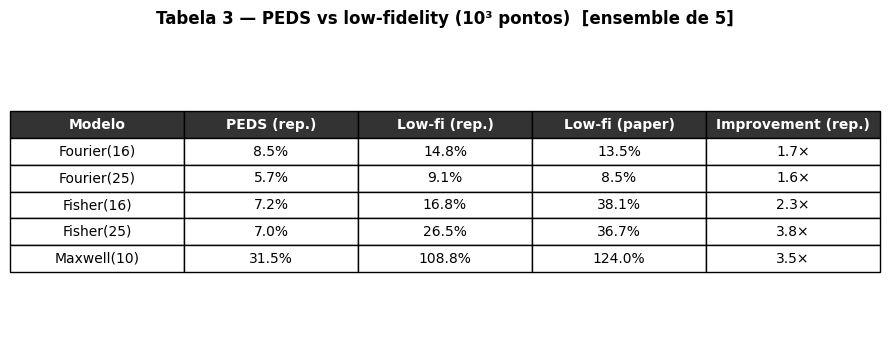

['./figs/tabela2_peds_vs_nn.png', './figs/tabela3_peds_vs_lowfi.png']

In [4]:
# Célula 4 — as 2 tabelas (replicado vs paper)
plot_replication_tables(results)

## Eficiência de dados — sweep de tamanho (premissa de "MENOS dados")
FE × nº de pontos (difusão). A tabela-veredito diz com quantos pontos cada modelo
atinge 5% e a economia de dados do PEDS. (Maxwell tem seu próprio gráfico na Célula 6.)

In [13]:
import importlib
import src.peds_experiments
importlib.reload(src.peds_experiments)
from src.peds_experiments import(run_size_sweep, plot_size_sweep, plot_efficiency_table, run_diffusion_experiment, plot_learning_curve, plot_replication_tables)

=== sweep Fourier(16) ===
  N=  256: PEDS=0.094  NN-only=0.118
  N=  512: PEDS=0.087  NN-only=0.102
  N= 1024: PEDS=0.085  NN-only=0.084
  N= 2048: PEDS=0.085  NN-only=0.081
  N= 4096: PEDS=0.085  NN-only=0.082


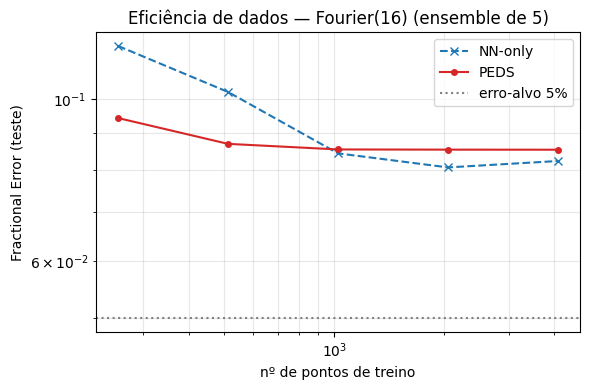

=== sweep Fourier(25) ===
  N=  256: PEDS=0.074  NN-only=0.113
  N=  512: PEDS=0.074  NN-only=0.105
  N= 1024: PEDS=0.058  NN-only=0.092
  N= 2048: PEDS=0.051  NN-only=0.092
  N= 4096: PEDS=0.045  NN-only=0.103


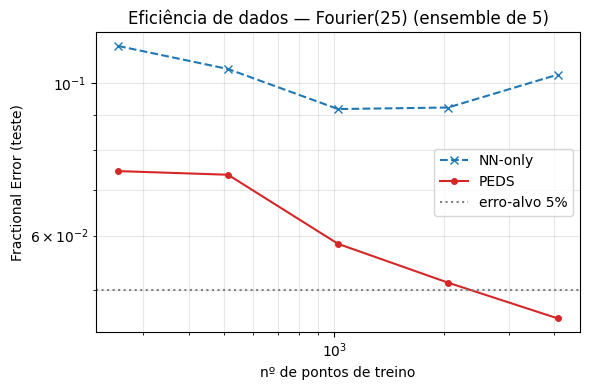

=== sweep Fisher(16) ===
  N=  256: PEDS=0.111  NN-only=0.156
  N=  512: PEDS=0.087  NN-only=0.126
  N= 1024: PEDS=0.073  NN-only=0.113
  N= 2048: PEDS=0.067  NN-only=0.105
  N= 4096: PEDS=0.059  NN-only=0.109


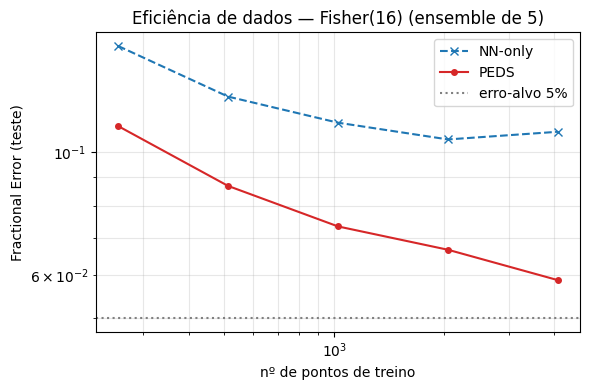

=== sweep Fisher(25) ===
  N=  256: PEDS=0.103  NN-only=0.149
  N=  512: PEDS=0.084  NN-only=0.133
  N= 1024: PEDS=0.071  NN-only=0.123
  N= 2048: PEDS=0.068  NN-only=0.125
  N= 4096: PEDS=0.061  NN-only=0.135


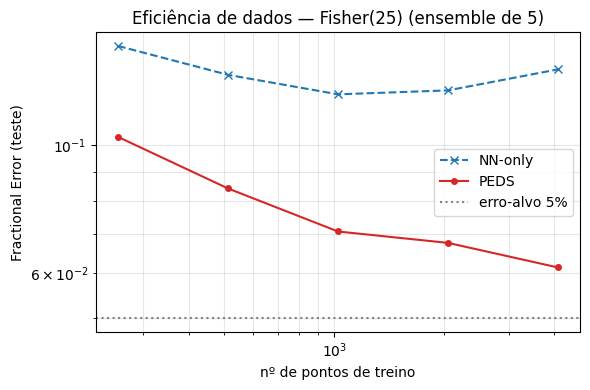

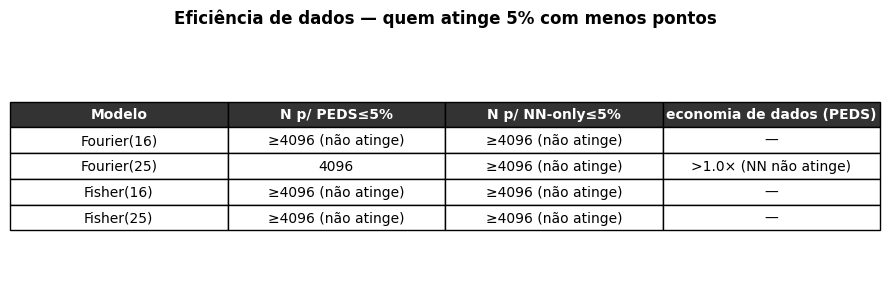

'./figs/tabela_eficiencia_dados.png'

In [14]:
# Célula 5 — sweep + tabela-veredito do 'mais com menos'
# n_ensemble=N_ENSEMBLE: cada ponto vira média de N_ENSEMBLE modelos (suaviza as curvas)
sweeps = []
for name in EXPERIMENTS:
    print(f'=== sweep {name} ===')
    sw = run_size_sweep(name, DATA_ROOT, sizes=[256,512,1024,2048,4096],
                        device=DEVICE, n_ensemble=N_ENSEMBLE)
    sweeps.append(sw); plot_size_sweep(sw, target=0.05)
plot_efficiency_table(sweeps, target=0.05)

## Maxwell — eficiência de dados + active learning (NN-only vs PEDS vs PEDS+AL)
Um único gráfico com as 3 curvas em FE × nº de pontos (análogo da Fig. 3).
**Mais pesado** (ensemble × T × FDFD, em 3 estratégias). Reproduz a estratégia de aquisição
do paper dentro dos 10k pontos rotulados — sem o solver HF não alcança o trecho de 500k.

  >>> PEDS + AL (aquisição por incerteza)
    [peds/al] iter 0: N=256 FE=0.426
    [peds/al] iter 1: N=384 FE=0.436
    [peds/al] iter 2: N=512 FE=0.370
    [peds/al] iter 3: N=640 FE=0.322
    [peds/al] iter 4: N=768 FE=0.313
    [peds/al] iter 5: N=896 FE=0.303
    [peds/al] iter 6: N=1024 FE=0.287
  >>> PEDS (aquisição aleatória = estático)
    [peds/random] iter 0: N=256 FE=0.426
    [peds/random] iter 1: N=384 FE=0.380
    [peds/random] iter 2: N=512 FE=0.332
    [peds/random] iter 3: N=640 FE=0.332
    [peds/random] iter 4: N=768 FE=0.301
    [peds/random] iter 5: N=896 FE=0.307
    [peds/random] iter 6: N=1024 FE=0.291
  >>> NN-only (aquisição aleatória)
    [base/random] iter 0: N=256 FE=0.819
    [base/random] iter 1: N=384 FE=0.806
    [base/random] iter 2: N=512 FE=0.777
    [base/random] iter 3: N=640 FE=0.734
    [base/random] iter 4: N=768 FE=0.706
    [base/random] iter 5: N=896 FE=0.670
    [base/random] iter 6: N=1024 FE=0.623


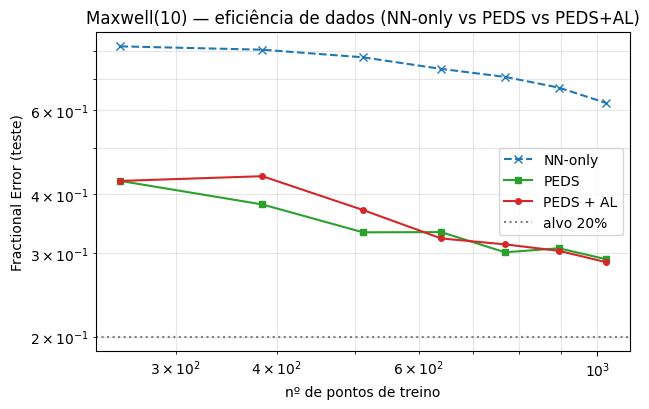

'./figs/active_learning_Maxwell10.png'

In [15]:
# Célula 6 — Maxwell: NN-only vs PEDS vs PEDS+AL  (LENTO)
al = run_maxwell_active_learning(DATA_ROOT, device=DEVICE,
                                 n_ensemble=3, ninit=256, T=6, M=4, K=128, epochs=8,
                                 grad_clip=1.0, compare_random=True, compare_nn=True)
plot_al_curve(al, target=0.20)